# (1) ABCD-o Graphs with the Python implementation

We use the Python implementation of ABCD: ```pip install abcd-graph```

We illustrate the following:
* generate and visualize a few small ABCD-o graphs with various number of outlier nodes
* generate larger ABCD-o graphs to test a simple outlier detection method under various noise levels

The main functions are:
* **ABCDParams** : specify the parameters for ABCD
* **ABCDGraph**(params).build() : generate the ABCD graph
* Graph.**exporter.to_igraph**() : export to igraph format

NB: Later in this notebook, we show how to use the **Julia** version of ABCD-0


In [1]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
%matplotlib inline
from collections import Counter
import partition_igraph
from sklearn.metrics import adjusted_mutual_info_score as AMI
from abcd_graph import ABCDGraph, ABCDParams
from sklearn.metrics import roc_curve, auc


## (1.1) Small ABCD-o graphs with 100 nodes and varying number of outliers

The ABCD parameters used to generate those graphs are: 
* $n=100$ (number of nodes)
* $\gamma=2.5$ (a.k.a. as 't1')
* degree range [5,15]
* $\beta=1.5$ (a.k.a. as 't2')
* community size range [30,40]
* $\xi = 0.2$
* $nout \in \{0, 10, 20, 30\}$, the number of outiliers

In [2]:
## Parameters

## number of nodes
n = 100

## degree distribution
gamma = 2.5
delta = 5
Delta = 15

## community sizes distribution
beta = 1.5
s = 30
S = 40

## noise parameters
xi = 0.2


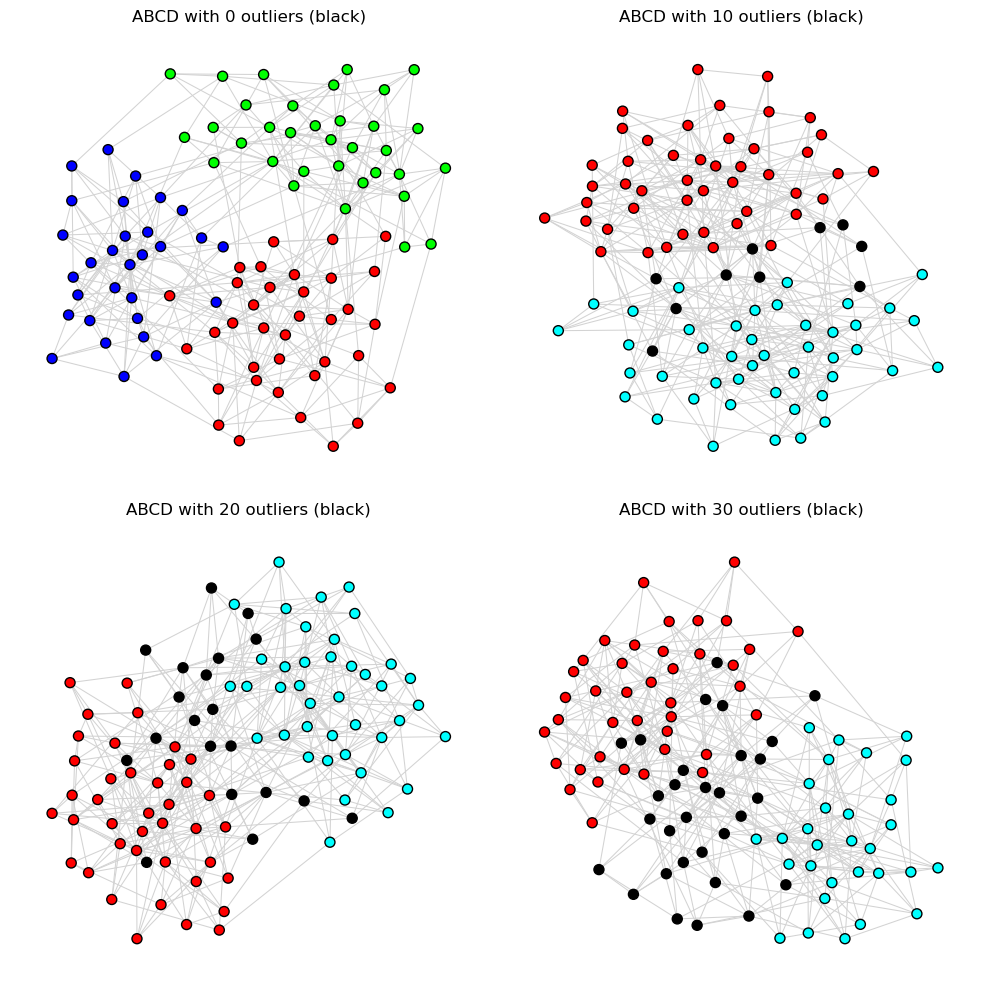

In [3]:
## Number of outliers
nout = [0,10,20,30]

fig, axs = plt.subplots(2, 2, figsize=(10, 10)) # You can adjust figsize as needed

## for reproducibility
random.seed(123)
np.random.seed(123)

for i in range(4):
    params = ABCDParams(vcount=n, gamma=gamma, min_degree=delta, max_degree=Delta, beta=beta, 
                        min_community_size=s, max_community_size=S, xi=xi, num_outliers=nout[i])
    g = ABCDGraph(params).build()
    g_abcd = g.exporter.to_igraph()

    g_abcd.vs['size'] = 10
    g_abcd.es['width'] = .75
    g_abcd.es['color'] = 'lightgrey'
    pal = ig.drawing.colors.RainbowPalette(n=max(g_abcd.vs['ground_truth_community'])+1)
    g_abcd.vs['color'] = [pal[i] if i>=0 else 'black' for i in g_abcd.vs['ground_truth_community']]
    ly = g_abcd.layout_fruchterman_reingold()
    ig.plot(g_abcd, target=axs[i//2,i%2], layout=ly, bbox=(0,0,400,300), Caption="Graph"+str(i))
    axs[i//2,i%2].set_title("ABCD with "+str(nout[i])+" outliers (black)")
plt.tight_layout()
plt.show()

## (1.2) Larger ABCD-o graphs - outlier detection

The ABCD-o parameters used: 
* $n=10000$ (number of nodes)
* $nout=1000$ (number of outliers)
* $\gamma=2.5$ (a.k.a. as 't1')
* degree range [10,100]
* $\beta=1.5$ (a.k.a. as 't2')
* community size range [200,1000]
* $0.4 \le \xi \le 0.75$

In [4]:
## number of nodes
n = 10000

## number of outlier nodes
nout = 1000

## degree distribution
gamma = 2.5
delta = 10
Delta = 100

## community sizes distribution
beta = 1.5
s = 200
S = 1000


In [5]:
## participation coefficient
def pc(G, A):
    deg = G.degree()
    coef = []
    for v in range(G.vcount()):
        coef.append(1-np.sum([(x/deg[v])**2 for x in Counter([A[i] for i in G.neighbors(v)]).values()]))
    return coef


### Experiment - outlier detection

For several values $0.4 \le \xi \le 0.75$, we follow those steps:
1. generate ABCD-o graph with above parameters
2. run Leiden to partition the graph
3. compute the participation coefficient (pc) for every node in the graph
4. show the ROC curve when using the participation coefficient to rank nodes as potential outliers

Details of the participation coefficients (pc) can be found in the textbook: https://www.torontomu.ca/mining-complex-networks/

In a nutshell, a low value for the pc is indicative of strong community membership, while outlier nodes tend to have a high pc value.

In the experiment below, we see that we can sucessfully detect most outliers when the noise value is 0.6 or less, while things quickly get much more difficult for higher noise levels. 


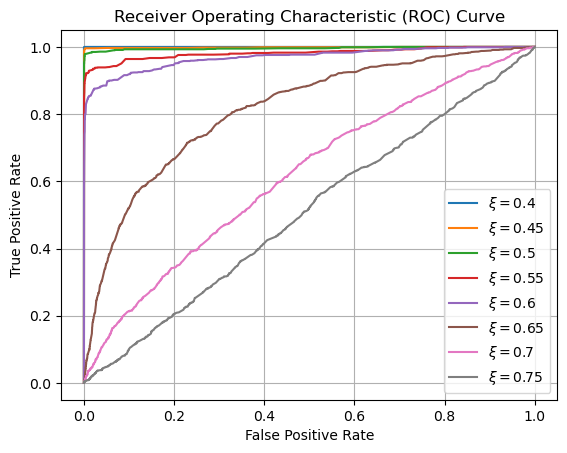

In [6]:
## for reproducibility
random.seed(321)
np.random.seed(321)

## vary the noise parameter
for xi in [.4,.45,.5,.55,.6,.65,.7,.75]:
    ## generate ABCD-o graph
    params = ABCDParams(vcount=n, gamma=gamma, min_degree=delta, max_degree=Delta, beta=beta, 
                        min_community_size=s, max_community_size=S, xi=xi, num_outliers=nout)
    g = ABCDGraph(params).build()
    g_abcd = g.exporter.to_igraph()

    ## flag outlier nodes
    outliers = np.array(g_abcd.vs['ground_truth_community'])==-1
    
    ## partition the graph with Leiden
    g_abcd.vs['leiden'] = g_abcd.community_leiden(objective_function='modularity').membership

    ## compute participation coefficient score w.r.t. Leiden communities
    score = pc(g_abcd, g_abcd.vs['leiden'])
    
    fpr, tpr, thresholds = roc_curve(outliers, score)
    #print('AUC:,',auc(fpr, tpr))
 
    plt.plot(fpr, tpr, label=r"$\xi=$"+str(xi))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()

# (2) Julia implementation of ABCD-o

Here we show how to use the Julia version of ABCD inside a Python notebook.
To call ABCD directly in Julia, for example via command line, please consult: https://github.com/bkamins/ABCDGraphGenerator.jl

The following needs to be installed:
* The Julia language: ```https://julialang.org/downloads/```
* PyJulia: ```pip install julia```

To install the ABCD Julia package, open Julia REPL (the command line interface) and enter:
```
using Pkg
Pkg.add(url="https://github.com/bkamins/ABCDGraphGenerator.jl")
```

In [7]:
import julia               ## PyJulia, installed via: pip install julia
julia.install(quiet=True)  ## adding the path to the 'julia' executable may be needed
from julia.api import Julia 
jl = Julia(compiled_modules=False) ## needed on macOS (at least)
%load_ext julia.magic


Initializing Julia interpreter. This may take some time...


## (2.1) Generate a small ABCD-o graph in Julia

* We use the Julia package ```ABCDGraphGenerator```
* In the following cell, the first line indicates that the cell contains Julia code.
* This generates the objects ```edges``` and ```clusters```, the ABCD-o graph

The Julia API functions are:
 
* ABCDGraphGenerator.**sample_degrees**: sample degrees of vertices following power law
* ABCDGraphGenerator.**sample_communities**: sample community sizes following power law
* ABCDGraphGenerator.**ABCDParams**: type holding information about sampled degrees, sampled cluster sizes and required mode of ABCD graph generation
* ABCDGraphGenerator.**gen_graph**: ABCD graph generator that uses ABCDParams specification


In [8]:
%%julia
using Pkg
using ABCDGraphGenerator
using Random

## seeding
seed = 1
Random.seed!(seed)

## global parameters for the ABCD graph
xi = 0.2
n = 150
nout = 10 # number of outliers
n = n - nout # non-outlires

## degree sequence generation
gamma = 2.5
d_min = 8
d_max = 20
d_max_iter = 1000
degs = ABCDGraphGenerator.sample_degrees(gamma, d_min, d_max, n+nout, d_max_iter)

## community sizes generation
beta = 1.5
c_min = 45
c_max = 75
c_max_iter = 1000
coms = ABCDGraphGenerator.sample_communities(beta, c_min, c_max, n, c_max_iter)
if nout > 0
    pushfirst!(coms, nout)
end    

## generate ABCD-oo graph
p = ABCDGraphGenerator.ABCDParams(degs, coms, nothing, xi, false, false, nout>0)
edges, clusters = ABCDGraphGenerator.gen_graph(p);


desc


Below, we access Julia object via the```jl``` prefix.


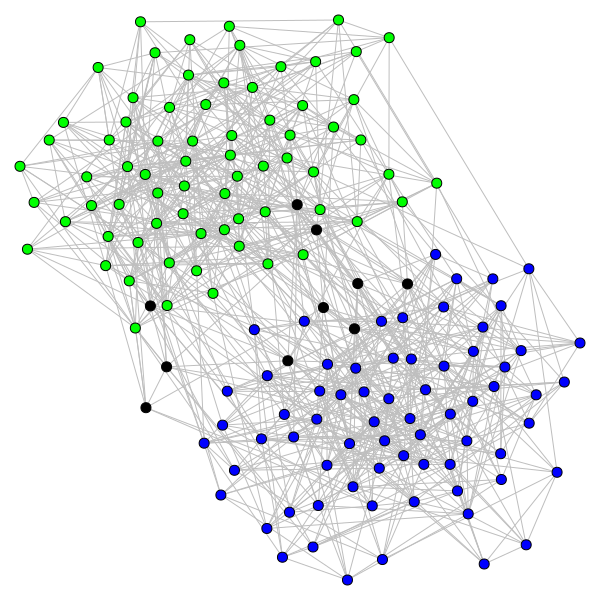

In [9]:
from julia import Main as jl ## to get the Julia variables in Python code

## Build igraph ABCD graph with communities 
Edges = list(jl.edges) ## 1-based in Julia
min_comm = 1
G = ig.Graph.TupleList(Edges)
G.vs['community'] = [int(jl.clusters[v-1])-1 for v in G.vs['name']]

## set node color
nc = max(jl.clusters)
my_pal = ig.drawing.colors.RainbowPalette(n=nc)
G.vs['color'] = [my_pal[i] if i>0 else 'black' for i in G.vs['community']]

## plot
ig.plot(G, bbox=(600,600), edge_color='grey', vertex_size=10)
